# Problem Type : Classification

# Task : Predict Survival

**🎯 Objective**

Predict whether a passenger survived (Survived = 1) or not (Survived = 0) using an ANN model.

```
Target Column:

Survived

Dataset Information

- Rows: 891
- Columns: 12
```

# **Step 1: Import Required Libraries**

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Evaluation
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    auc
)

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

# **Step 2: Load Dataset**

In [2]:
df = pd.read_csv('/content/Titanic Dataset.csv')

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **Step 3: Basic Information**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,1601,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


# **Step 4: Check Missing Values**

In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Missing Values Found**

| Column   | Missing |
| -------- | ------- |
| Age      | 177     |
| Cabin    | 687     |
| Embarked | 2       |


# **Step 5: Handle Missing Values**
**Age → Median**

In [8]:
df['Age'].fillna(df['Age'].median(), inplace=True)

**Embarked → Mode**

In [9]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

**Cabin → Drop (Too Many Missing Values)**

In [10]:
df.drop('Cabin', axis=1, inplace=True)

# **Step 6: Exploratory Data Analysis (EDA)**
**Survival Count**

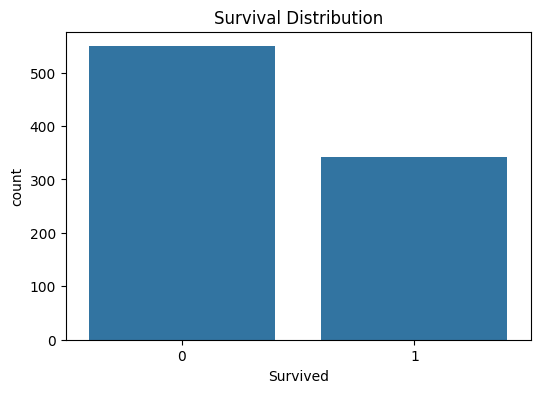

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x='Survived', data=df)

plt.title('Survival Distribution')

plt.show()

**Survival by Gender**

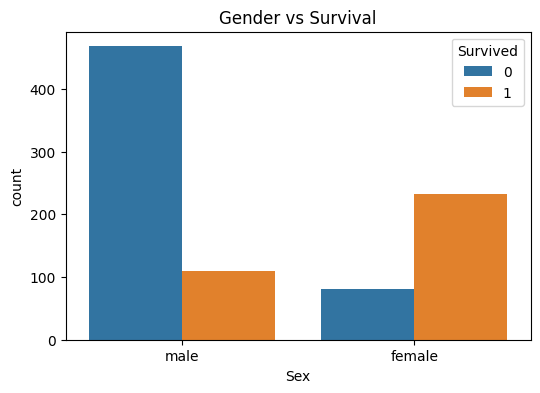

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title('Gender vs Survival')

plt.show()

**Passenger Class vs Survival**

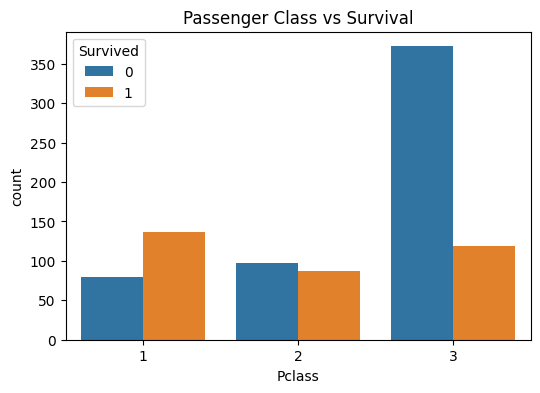

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title('Passenger Class vs Survival')

plt.show()

**Age Distribution**

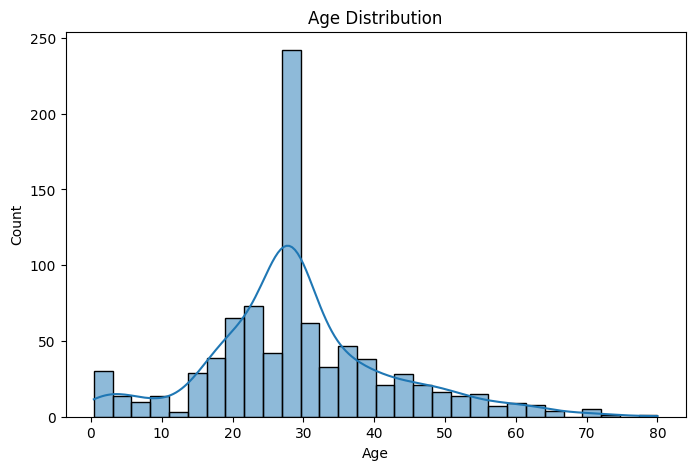

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title('Age Distribution')

plt.show()

**Correlation Heatmap**

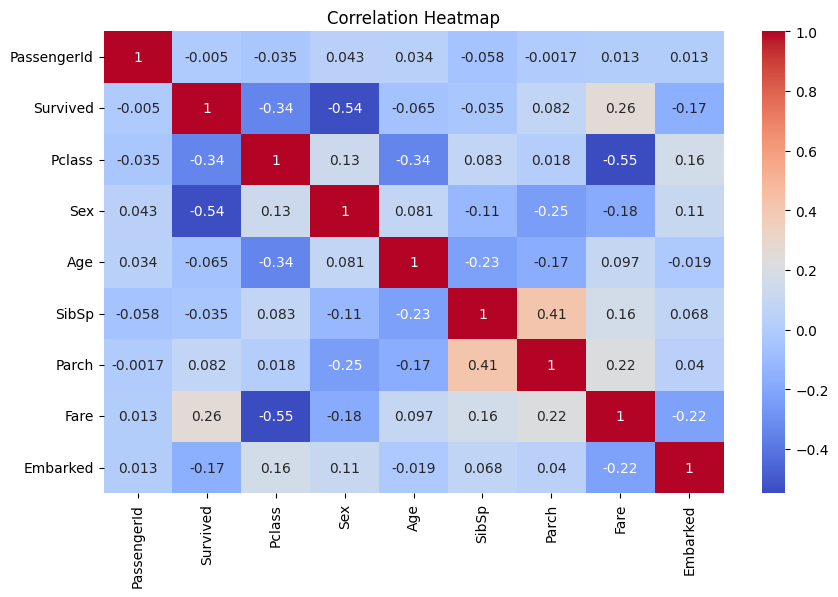

In [17]:
temp_df = df.copy()

for col in ['Sex','Embarked']:
    temp_df[col] = LabelEncoder().fit_transform(temp_df[col])

temp_df = temp_df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(temp_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

# **Step 7: Feature Selection**
**Drop Unnecessary Columns**

These columns are mostly unique identifiers or high-cardinality text:

In [19]:
df.drop(
    columns=[
        'PassengerId',
        'Name',
        'Ticket'
        ],
    inplace=True
)

# **Step 8: Encode Categorical Variables**

In [20]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

Check :

In [21]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


# **Step 9: Split Features and Target**

In [22]:
X = df.drop('Survived', axis=1)

y = df['Survived']

# **Step 10: Feature Scaling**

ANN works better on scaled data.

In [23]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# **Step 11: Train-Test Split**

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(712, 7)
(179, 7)


# **Step 12: Build ANN Model**
**Architecture**

Input Layer → 16 Neurons → 8 Neurons → Output Layer

In [25]:
ann = Sequential()

# Hidden Layer 1
ann.add(Dense(
    units=16,
    activation='relu',
    input_dim=X_train.shape[1]
))

ann.add(Dropout(0.2))

# Hidden Layer 2
ann.add(Dense(
    units=8,
    activation='relu'
))

ann.add(Dropout(0.2))

# Output Layer
ann.add(Dense(
    units=1,
    activation='sigmoid'
))

# **Step 13: Compile Model**

In [26]:
ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# **Step 14: Model Summary**

In [27]:
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

# **Step 15: Early Stopping**

In [28]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# **Step 16: Train ANN Model**

In [29]:
history = ann.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - accuracy: 0.5501 - loss: 0.6868 - val_accuracy: 0.6294 - val_loss: 0.6563
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6643 - loss: 0.6467 - val_accuracy: 0.7133 - val_loss: 0.6301
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6485 - loss: 0.6230 - val_accuracy: 0.7203 - val_loss: 0.6076
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6555 - loss: 0.6188 - val_accuracy: 0.7273 - val_loss: 0.5902
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7083 - loss: 0.5843 - val_accuracy: 0.7203 - val_loss: 0.5760
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6942 - loss: 0.5851 - val_accuracy: 0.7203 - val_loss: 0.5620
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7329 - loss: 0.5558 - val_accuracy: 0.7203 - val_loss: 0.5498
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7188 - loss: 0.5563 - val_accuracy: 0.7413 -

# **Step 17: Training Accuracy Graph**

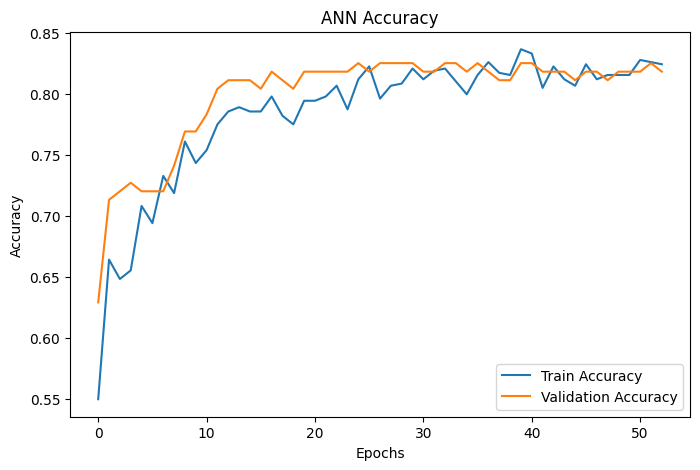

In [31]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         label='Train Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.title('ANN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# **Step 18: Loss Graph**

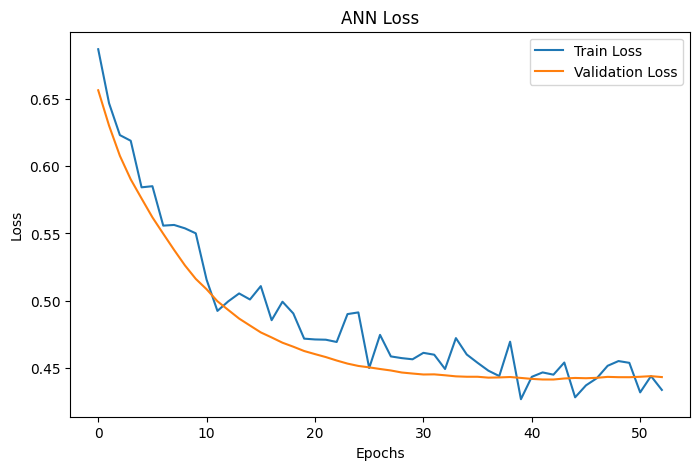

In [32]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Train Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title('ANN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# **Step 19: Predictions**

In [36]:
y_prob = ann.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step 


# **Step 20: Accuracy Score**

In [37]:
acc = accuracy_score(y_test, y_pred)

print("Accuracy :", round(acc*100,2), "%")

Accuracy : 81.56 %


# **Step 21: Confusion Matrix**

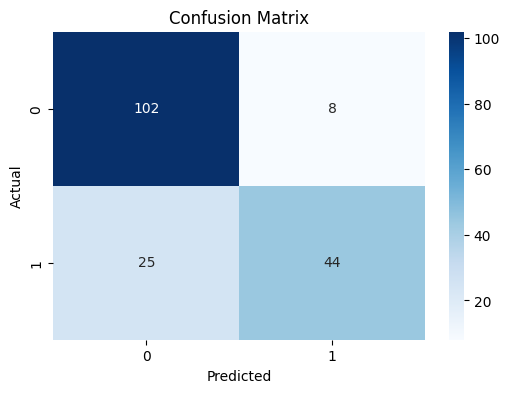

In [38]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# **Step 22: Classification Report**

In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.93      0.86       110
           1       0.85      0.64      0.73        69

    accuracy                           0.82       179
   macro avg       0.82      0.78      0.79       179
weighted avg       0.82      0.82      0.81       179



# **Step 23: ROC-AUC Curve**

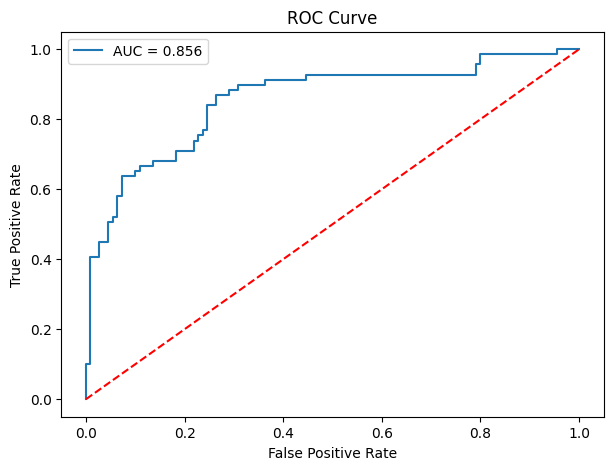

In [40]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.3f}'
)

plt.plot([0,1],[0,1],'r--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

# **Step 24: Predict New Passenger**

**Example Passenger**

| Feature  | Value |
| -------- | ----- |
| Pclass   | 3     |
| Sex      | Male  |
| Age      | 25    |
| SibSp    | 0     |
| Parch    | 0     |
| Fare     | 7.25  |
| Embarked | S     |


In [42]:
new_passenger = pd.DataFrame({
    'Pclass':[3],
    'Sex':[1],       # Male=1
    'Age':[25],
    'SibSp':[0],
    'Parch':[0],
    'Fare':[7.25],
    'Embarked':[2]   # S=2
})

# Scale Input
new_scaled = scaler.transform(new_passenger)

# Predict
prediction = ann.predict(new_scaled)

print("Probability of Survival:",
      prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Probability of Survival: 0.10133512


 **Final Result**

In [43]:
if prediction > 0.5:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

Passenger Did Not Survive
